In [1]:
import scanpy as sc
import infercnvpy as cnv
import numpy as np

adata = sc.read_h5ad("data/processed/03_annotated.h5ad")
print(adata.shape, "| cell types:", adata.obs["cell_type"].unique().tolist())

/home/ubuntu/miniconda3/envs/scrna/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/ubuntu/miniconda3/envs/scrna/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(31265, 2000) | cell types: ['ER+ tumor', 'Myeloid', 'Fibroblast', 'TNBC tumor', 'Endothelial', 'T cell', 'Plasma cell']


In [ ]:
#only 2000 genes (the HVGs). CNV needs the full gene set, not just 2000, because it smooths across all genes along each chromosome

In [2]:
# CNV needs ALL genes (smoothing along chromosomes), not just the 2000 HVGs.
# Restore the full gene set from .raw (frozen in Stage 2).
adata_cnv = adata.raw.to_adata()
adata_cnv.obs = adata.obs.copy()          # carry over cell_type, subtype labels
print("Full gene set restored:", adata_cnv.shape)

Full gene set restored: (31265, 22844)


In [ ]:
# We are not aware of each gene's chromosome and position. 
# Right now your genes are just names (GATA3, ESR1...) with no coordinates

In [5]:
# Fetch each gene's chromosome + position from Ensembl (needed for smoothing)
cnv.io.genomic_position_from_biomart(
    adata_cnv,
    biomart_gene_id="hgnc_symbol"   # our genes are symbols, not Ensembl IDs
)
print("Genes with position info:")
print(adata_cnv.var[["chromosome", "start", "end"]].dropna().shape[0], "of", adata_cnv.n_vars)

Genes with position info:
16564 of 22844


In [4]:
#  Genomic position annotation for CNV 
#
# Used infercnvpy biomart (live Ensembl query) to attach chromosome/start/end
# to each gene. 
# Result: 16,564 of 22,844 genes positioned (~72%).
#
# WHY BIOMART vs GTF (reproducibility tradeoff):
#   - Biomart queries Ensembl LIVE - answer can drift as Ensembl updates
#     (new releases change coords/symbols) and depends on server availability.
#   - A GTF file is a FROZEN snapshot → identical result forever, offline.
#   - For a production/clinical pipeline: pin a GENCODE GTF for exact reproducibility.
#   - For this portfolio: biomart result is solid; tradeoff noted. Judgment = knowing
#     which context demands which, not "always use GTF."
#
# WHY ~28% GENE DROP IS FINE FOR CNV (but would NOT be for DE):
#   1. CNV is a REGIONAL average — a sliding window smooths ~100 neighboring genes
#      to call a region gained/lost. It needs genome-wide COVERAGE, not COMPLETENESS.
#      No individual gene matters; the regional average does. 16.5k genes blanket
#      the genome densely --> every window still has plenty to average.
#   2. Dropped genes are SCATTERED (random symbol/aliasing misses), not clustered on
#      one chromosome --> no region goes dark.
#   3. 16.5k >> what inferCNV needs (default window = 100 genes). Far past the
#      threshold where coverage would degrade.

#   CONTRAST: differential expression cares about each specific gene's value, so
#   losing a marker (e.g. GATA3) would hurt. CNV measures TERRITORY, not specific
#   genes — robust to scattered loss.
#
# The two drop messages decoded:
#   - "5070 missing annotation" = Ensembl had no position for those symbols (outdated/
#     non-standard names).
#   - "44631 duplicate identifiers" = deduplication of multi-mapping entries, NOT loss
#     of real genes.

In [6]:
# Running CNV inference — smooth expression along chromosomes, per cell,
# comparing against normal (immune/stromal) reference cells
cnv.tl.infercnv(
    adata_cnv,
    reference_key="cell_type",
    reference_cat=["T cell", "Myeloid", "Fibroblast", "Endothelial", "Plasma cell"],
    window_size=100,
)
print("CNV inference done.")

100%|████████████████████████████████████████████| 7/7 [00:20<00:00,  2.90s/it]

CNV inference done.


In [7]:
# Compute a per-cell CNV score (total chromosomal disruption) + cluster on CNV
cnv.tl.pca(adata_cnv)
cnv.pp.neighbors(adata_cnv)
cnv.tl.leiden(adata_cnv)
cnv.tl.cnv_score(adata_cnv)
print("CNV score computed.")
print(adata_cnv.obs.groupby("cell_type")["cnv_score"].mean())

/home/ubuntu/miniconda3/envs/scrna/lib/python3.10/site-packages/infercnvpy/tl/__init__.py:24: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  return sc.tl.leiden(


CNV score computed.
cell_type
ER+ tumor      0.009248
Endothelial    0.007118
Fibroblast     0.007088
Myeloid        0.006904
Plasma cell    0.006924
T cell         0.007102
TNBC tumor     0.012971
Name: cnv_score, dtype: float64


/tmp/ipykernel_2820/3256361887.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata_cnv.obs.groupby("cell_type")["cnv_score"].mean())


In [ ]:
# CNV score results: per-cell-type mean (the key finding) 
#
# Mean cnv_score by cell type:
#   TNBC tumor     0.0130   ← highest chromosomal disruption
#   ER+ tumor      0.0092   ← second highest
#   Endothelial    0.0071
#   T cell         0.0071
#   Fibroblast     0.0071
#   Plasma cell    0.0069
#   Myeloid        0.0069   ← immune/stromal all cluster LOW
#
# INTERPRETATION — two findings:
#
# 1. Tumor cells score clearly above immune/stromal cells.
#    --> The annotated tumor cells carry genuine chromosomal abnormalities,
#      confirming they are truly MALIGNANT, not just "epithelial by marker."
#      An independent genomic test validates the Stage 3 annotation.
#
# 2. TNBC (0.013) > ER+ (0.009) in CNV score.
#    --> TNBC shows greater genomic instability than ER+. This recovers KNOWN
#      clinical biology — TNBC is documented as more genomically unstable — independently from our own data.
#
#   Immune/stromal cells sit at ~0.007, NOT zero. They are the
#   reference, so they define the baseline noise floor, not a true zero. The
#   SIGNAL is the GAP between tumor and normal, not the absolute values.
#
#   Hemnce, CNV confirms tumor cells are genomically abnormal AND that TNBC is
#   more unstable than ER+ (a per-cell finding bulk RNA-seq cannot produce).
#   Bulk could detect sample-level CNV but never localize it to individual cells
#   or separate malignant epithelium from normal cells in the same cluster.

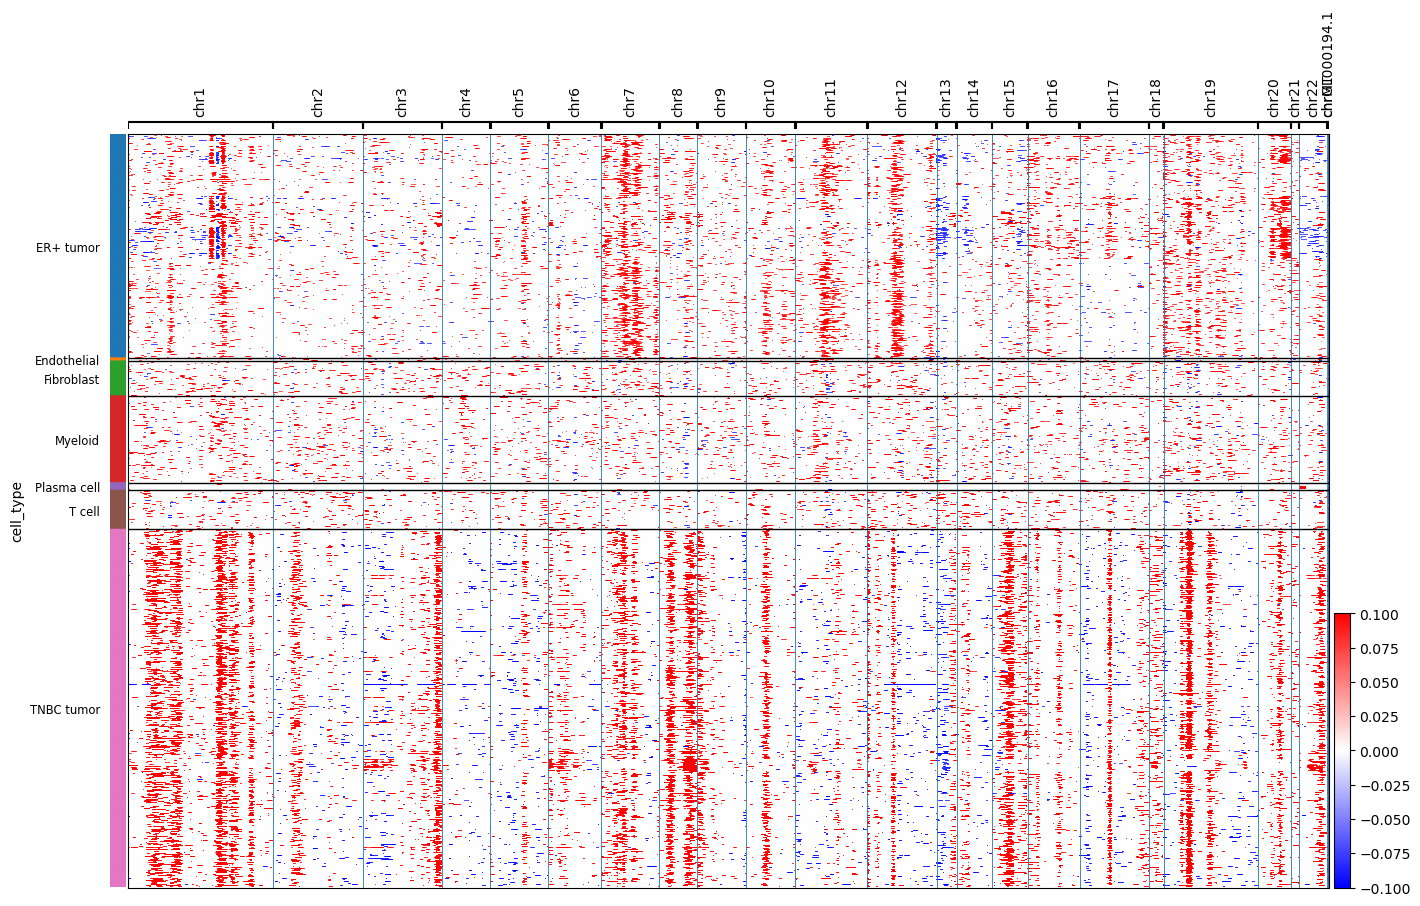

In [9]:
#genome-wide CNV landscape
cnv.pl.chromosome_heatmap(adata_cnv, groupby="cell_type", vmin=-0.1, vmax=0.1)

In [ ]:
# CNV chromosome heatmap 
# Color scale tightened to ±0.1 to match the data's actual CNV magnitude
# (default ±2.5 would have washed out the signal).
#
# READS: columns = genome position (chr1→chr22); rows = cells grouped by type;
#   red = gain, blue = loss, white = normal.
#
# RESULT (visual confirmation of the cnv_score finding):
#   - ER+ & TNBC tumor rows = heavily streaked red/blue → genome-wide CNVs.
#   - TNBC visibly MORE disrupted than ER+ (matches scores 0.013 > 0.009).
#   - Immune/stromal rows (T, myeloid, fibroblast, endo, plasma) = flat/white = normal.
#
# This is the figure bulk RNA-seq cannot produce: malignancy shown cell-by-cell,
# separating true cancer cells from adjacent normal cells.

In [10]:
# Save the CNV-analyzed object
adata_cnv.write("data/processed/04_cnv.h5ad")
import os
print("Saved:", os.path.exists("data/processed/04_cnv.h5ad"), adata_cnv.shape)

Saved: True (31265, 22844)


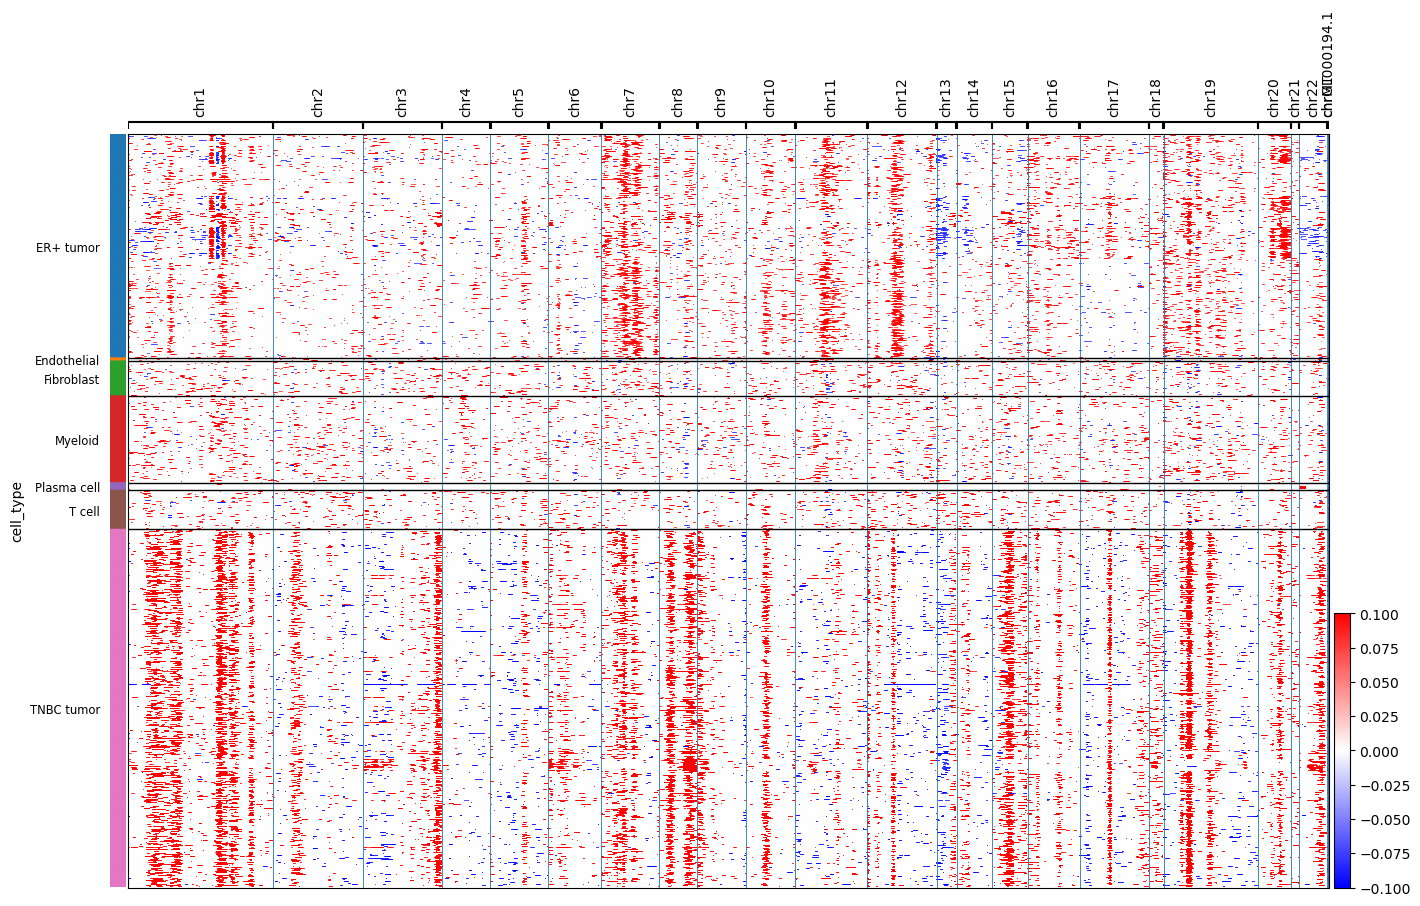

In [11]:
cnv.pl.chromosome_heatmap(adata_cnv, groupby="cell_type", vmin=-0.1, vmax=0.1,
                          save="_cnv_heatmap.png")